
(1) === Pola makan dengan skor sehat > 0 ===
 SampleID     Sisa       Skor  Sehat
        0  82000.0 100.776678    6.2
        1 134000.0  96.461251    2.8
        2  65000.0 101.523989    5.3
        3  82000.0 103.652137    4.0
        4 109000.0  94.181664    3.6
        5  81000.0 100.750009    2.8
        6 118000.0  98.015889    3.5
        7  91000.0  97.922521    2.3
        8  83000.0  98.899770    6.2
        9 130000.0  91.979039    3.8
       10 142000.0  93.619450    1.3
       11 106000.0 100.423836    4.7
       12  83000.0 106.512632    6.5
       13  91000.0 103.846545    6.6
       14 132000.0  99.868448    3.7
       15  84000.0 104.473354    4.6
       16 105000.0  93.790000    5.0
       17  92000.0 100.896511    4.4
       18 109000.0 100.788722    5.6
       19 115000.0  99.689272    3.4
       20  95000.0  96.588665    2.4
       21 131000.0  94.822319    3.5
       22 102000.0  98.608966    3.7
       23 103000.0  99.602055    7.1
       24 131000.0  95.172668

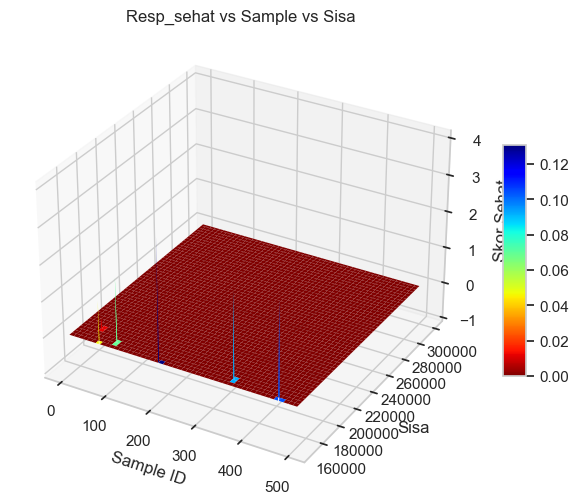

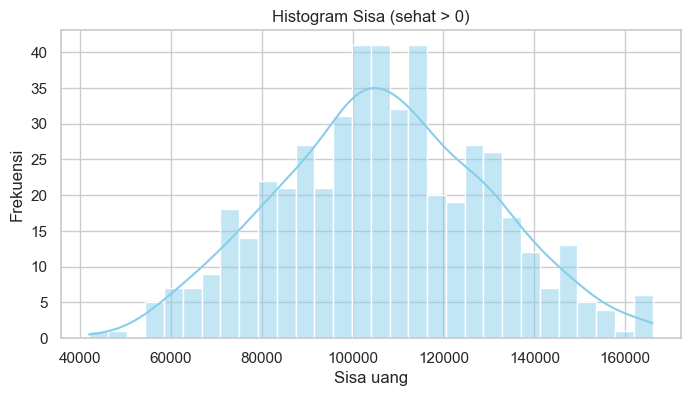

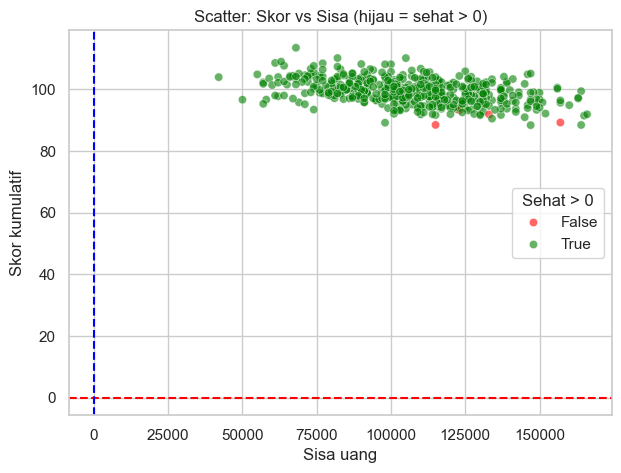

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset makanan
makan = pd.read_csv("makanan_new.csv")

NPM = 19102
np.random.seed(NPM)

budget_awal = 1e6  # rupiah

# Bobot dasar
wkenyang_base = 0.8
wrasa_base = 0.7
wsehat_base = 0.9  # simpangan lebih besar
wbosan_base = 0.2

SAMPLE_NUM = 500
sampleid = np.arange(SAMPLE_NUM)

# Array hasil simulasi
skor = np.zeros(SAMPLE_NUM, dtype=np.double)
sisa = np.zeros(SAMPLE_NUM, dtype=np.double)
sehat = np.zeros(SAMPLE_NUM, dtype=np.double)
resp_pilih = np.zeros((SAMPLE_NUM, 62), dtype=np.int32)  # 31 hari x 2 makan

SISA_MINIMUM = 150e3
SISA_MAKSIMUM = 300e3
bin_sisa = np.arange(SISA_MINIMUM, SISA_MAKSIMUM, 1000)
resp_sehat = np.zeros((SAMPLE_NUM, len(bin_sisa)), dtype=np.double)

# Simulasi
for n in range(SAMPLE_NUM):
    budget = budget_awal
    skor_kumulatif = 0
    skor_sehat = 0

    for i in range(31):  # 31 hari
        # Makan pagi
        pilihan = np.random.randint(0, len(makan))
        w_kenyang = np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa = np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat = np.random.normal(loc=wsehat_base, scale=0.4)
        w_bosan = np.random.normal(loc=wbosan_base, scale=0.2)

        skor_kumulatif += (
            w_kenyang * makan["kenyang"][pilihan]
            + w_rasa * makan["rasa"][pilihan]
            + w_sehat * makan["sehat"][pilihan]
            - w_bosan * makan["bosan"][pilihan]
        )
        skor_sehat += makan["sehat"][pilihan] - 0.5
        budget -= makan["harga"][pilihan]
        resp_pilih[n][2 * i] = pilihan

        # Makan malam
        pilihan = np.random.randint(0, len(makan))
        w_kenyang = np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa = np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat = np.random.normal(loc=wsehat_base + 0.2, scale=0.4)
        w_bosan = np.random.normal(loc=wbosan_base * 2, scale=0.2)

        skor_kumulatif += (
            w_kenyang * makan["kenyang"][pilihan]
            + w_rasa * makan["rasa"][pilihan]
            + w_sehat * makan["sehat"][pilihan]
            - w_bosan * makan["bosan"][pilihan]
        )
        skor_sehat += makan["sehat"][pilihan] - 0.5
        budget -= makan["harga"][pilihan]
        resp_pilih[n][2 * i + 1] = pilihan

    sisa[n] = budget
    skor[n] = skor_kumulatif
    sehat[n] = skor_sehat

    if SISA_MINIMUM <= budget < SISA_MAKSIMUM:
        idx = int((budget - SISA_MINIMUM) / 1000)
        resp_sehat[n][idx] = skor_sehat

# SOAL
# (1) Cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat) positif
samples_pos = np.where(sehat > 0)[0]
df_pos = pd.DataFrame({
    "SampleID": samples_pos,
    "Sisa": sisa[samples_pos],
    "Skor": skor[samples_pos],
    "Sehat": sehat[samples_pos]
})
print("\n(1) === Pola makan dengan skor sehat > 0 ===")
print(df_pos.to_string(index=False))

# (2) Cari titik-titik dengan sisa uang bulanan positif dari (1)
samples_pos_sisa = np.where((sehat > 0) & (sisa > 0))[0]
df_pos_sisa = pd.DataFrame({
    "SampleID": samples_pos_sisa,
    "Sisa": sisa[samples_pos_sisa],
    "Skor": skor[samples_pos_sisa],
    "Sehat": sehat[samples_pos_sisa]
})
print("\n(2) === Titik dengan sehat > 0 & sisa > 0 ===")
print(df_pos_sisa.to_string(index=False))

# (3) Cari titik dengan skor skumulatif terbesar (skor) di mana nilai kumulatif kesehatannya positif
valid_idx = np.where(sehat > 0, skor, -np.inf)
best_idx = np.argmax(valid_idx)

df_best = pd.DataFrame({
    "SampleID": [best_idx],
    "Sisa": [sisa[best_idx]],
    "Skor": [skor[best_idx]],
    "Sehat": [sehat[best_idx]]
})
print("\n(3) === Sampel terbaik (skor max, sehat > 0) ===")
print(df_best.to_string(index=False))

# (4) Tampikan jadwal makanan sesuai pilihan (resp_pilih)
jadwal_best = [makan["makanan"][resp_pilih[best_idx][j]] for j in range(62)]
df_best_schedule = pd.DataFrame({
    "Hari": np.repeat(np.arange(1, 32), 2),
    "Waktu": ["Pagi", "Malam"] * 31,
    "Makanan": jadwal_best,
})
print("\n(4) === Jadwal makanan terbaik ===")
print(df_best_schedule.to_string(index=False))

# Visualisasi
sns.set(style="whitegrid")

# 3D surface plot 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
Y, X = np.meshgrid(bin_sisa, sampleid)
surf = ax.plot_surface(X, Y, resp_sehat, cmap="jet_r", edgecolor="none")
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_title("Resp_sehat vs Sample vs Sisa")
ax.set_xlabel("Sample ID")
ax.set_ylabel("Sisa")
ax.set_zlabel("Skor Sehat")
plt.show()

# Histogram sisa (sehat > 0) 
plt.figure(figsize=(8, 4))
sns.histplot(sisa[samples_pos], bins=30, kde=True, color="skyblue")
plt.title("Histogram Sisa (sehat > 0)")
plt.xlabel("Sisa uang")
plt.ylabel("Frekuensi")
plt.show()

# Scatter skor vs sisa 
plt.figure(figsize=(7, 5))
sns.scatterplot(x=sisa, y=skor, hue=sehat > 0,
                palette={True: "green", False: "red"}, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.axvline(0, color="blue", linestyle="--")
plt.title("Scatter: Skor vs Sisa (hijau = sehat > 0)")
plt.xlabel("Sisa uang")
plt.ylabel("Skor kumulatif")
plt.legend(title="Sehat > 0")
plt.show()